# FX Liquidity Risk


## What Is Liquidity Risk?

**Liquidity risk** is the risk that market participants cannot **buy or sell an asset at a fair price and in the desired size, at short notice, and without excessive market impact**. In foreign exchange, liquidity risk shows up in two distinct flavours:

| Type | Focus | Real-world manifestation |
|---|---|---|
| **Market liquidity risk** | Ability to transact in the FX market | Wide bid-ask spreads, thin order-book depth, large slippage, price gaps in stress, exotic/less-traded pairs |
| **Funding liquidity risk** | Ability to raise cash / meet payment obligations | Not having the right currency at the right time, settlement (Herstatt) risk, inability to fund margin calls |

A **money-transfer / FX provider** (e.g. a remittance or cross-border payments business) lives on both: it must quote competitive, executable FX rates in real time (**market liquidity**) while ensuring it can always fund and settle customer flows across currencies and time zones (**funding liquidity**).

## Why FX Liquidity Matters for an FX Provider

- **Pricing**: a provider's margin is the difference between the *interbank* (live, deep) rate and the *customer* rate. Thin market liquidity raises the cost of covering a client trade, squeezing margins or forcing wider spreads.
- **Execution risk**: when a customer order is large or illiquid, filling it in the market moves the price (impact cost). Underestimating impact destroys the P&L of the trade.
- **Balancing risk**: a provider with inflows and outflows in different currencies and timings must keep internal positions balanced; excess currency balances need to be recycled, exposing them to liquidity and FX risk.
- **Settlement / funding risk**: payments must arrive **today** in the target currency. If the provider cannot fund an outgoing leg, it risks a failed or delayed transfer &mdash; settlement risk.

In this notebook we measure market liquidity (spreads, depth, impact, illiquidity), quantify it with **liquidity-adjusted VaR**, and finally model **funding/settlement** liquidity risk and how to mitigate it.

## A note on the FX notation

We work as before with the exchange rate $S_t$, i.e. the price of **one unit of foreign currency in domestic currency**. The **log return** is $r_t = \log(S_t/S_{t-1})$. Throughout we use an EUR/USD style pair (EUR as domestic).

In [1]:
import math
import numpy as np
import pandas as pd
from pylab import plt, mpl
np.set_printoptions(suppress=True)

In [2]:
plt.style.use('seaborn-v0_8')
mpl.rcParams['figure.dpi'] = 130
mpl.rcParams['savefig.dpi'] = 130
mpl.rcParams['font.family'] = 'serif'
from numpy.random import default_rng
rng = default_rng(1000)  # reproducible

## Step 1 &mdash; Simulating an Exchange Rate (GBM)

We reuse the **Geometric Brownian Motion (GBM)** machinery for the mid (fair) exchange rate:

$$dS_t = \mu S_t\, dt + \sigma S_t\, dW_t$$

over one trading year (252 steps), with $S_0 = 1.08$ (EUR price of 1 USD), drift $\mu = 0.0$ and annualized volatility $\sigma = 0.07$ (a realistic EUR/USD-like number). This **mid rate** is what a deeply liquid interbank market would quote. Our goal is to understand how much *extra* cost liquidity frictions add on top of this mid rate.

Daily parameters: $\sigma_{dt} = \sigma/\sqrt{252}$ and $\mu_{dt} = (\mu-\sigma^2/2)\,dt$.

In [3]:
S0 = 1.08          # initial mid exchange rate (EUR/USD)
mu = 0.0           # annual drift
sigma = 0.07       # annualized volatility
M = 252            # daily steps (one trading year)
dt = 1 / M

mu_dt = (mu - 0.5 * sigma ** 2) * dt
sigma_dt = sigma * math.sqrt(dt)

def gbm_path(S0, mu_dt, sigma_dt, M, rng):
    '''Simulate one GBM path of length M+1 (starts at S0).'''
    S = np.zeros(M + 1)
    S[0] = S0
    z = rng.standard_normal(M)
    S[1:] = S0 * np.exp(np.cumsum(mu_dt + sigma_dt * z))
    return S

dates = pd.bdate_range(end=pd.Timestamp.today().normalize(), periods=M + 1)
S = gbm_path(S0, mu_dt, sigma_dt, M, rng)

fx = pd.DataFrame(S, index=dates, columns=['S'])
fx['r'] = np.log(fx['S'] / fx['S'].shift(1))
fx.dropna(inplace=True)
fx.head()

,S,r
2025-09-25,1.078460,-0.001427
2025-09-26,1.076143,-0.002151
2025-09-29,1.084134,0.007399
2025-09-30,1.093585,0.008679
2025-10-01,1.094323,0.000675


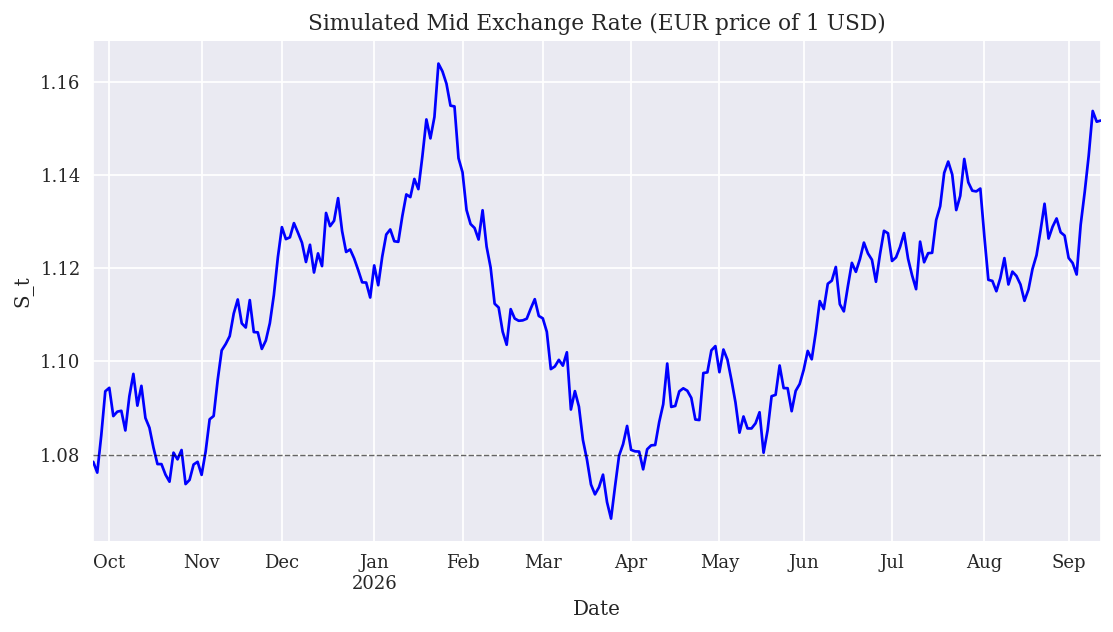

In [4]:
fig, ax = plt.subplots(figsize=(10, 5))
fx['S'].plot(ax=ax, lw=1.5, c='b')
ax.set(title='Simulated Mid Exchange Rate (EUR price of 1 USD)',
       ylabel='S_t', xlabel='Date')
ax.axhline(S0, color='k', ls='--', lw=0.8, alpha=0.6)
plt.show()

## Step 2 &mdash; Bid-Ask Spread and Effective Cost

The **bid-ask spread** is the most visible measure of market liquidity: the midpoint minus half the spread is the **bid** (what you can sell at), the midpoint plus half the spread is the **ask** (what you can buy at). For a round trip (buy **and** sell) you pay roughly the full spread.

For a liquid EUR/USD, the spread might be a handful of **pips** (1 pip = 0.0001) on the interbank market. We model the half-spread in **relative** terms (basis points of the mid rate) and make it state-dependent: spreads **widen** when volatility is high (liquidity worsens exactly when you need it most).

$$half_t = c_0 + c_1\,|r_t|/\sigma_{dt}$$

Daily half-spread (bps): mean = 9.24, min = 3.01, max = 23.32
Median one-way cost for 1 EUR = 8.54 bps
Median round-trip cost for 1 EUR = 17.09 bps


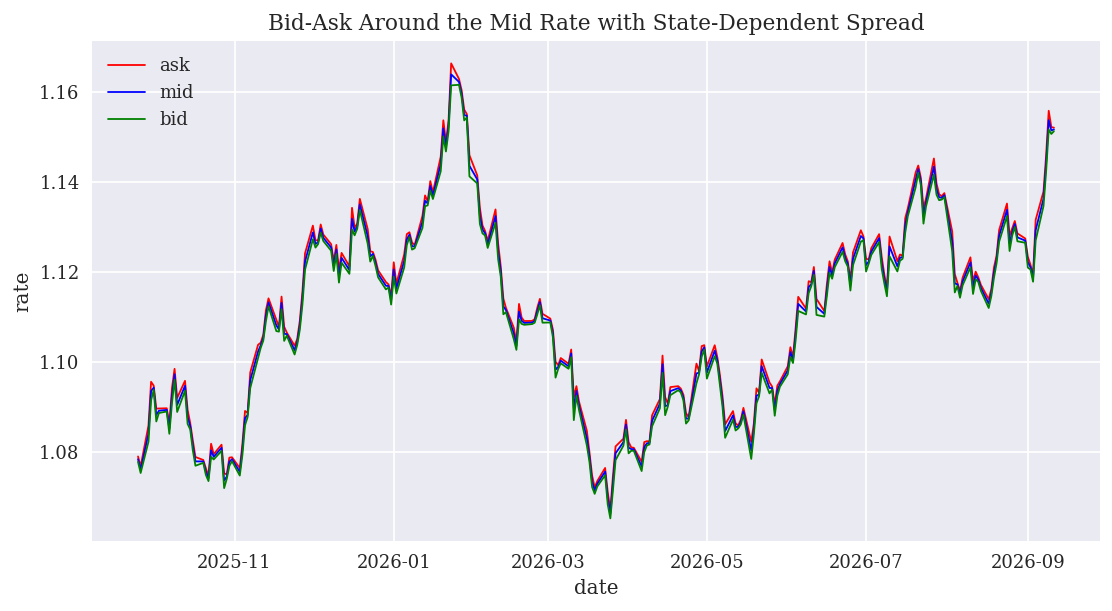

In [5]:
# half-spread model: base + sensitivity to volatility (in bps)
c0 = 3.0                 # base half-spread in bps
c1 = 8.0                 # extra bps per unit of |return|/vol
zr = np.abs(fx['r'].values) / sigma_dt
half_bp = c0 + c1 * zr                 # half-spread in basis points
half = half_bp / 10000                 # convert to relative

mid = fx['S'].values
bid = mid * (1 - half)
ask = mid * (1 + half)
spread = ask - bid

fx['half_bp'] = half_bp
fx['bid'] = bid
fx['ask'] = ask
fx['spread'] = spread

print('Daily half-spread (bps): mean = %.2f, min = %.2f, max = %.2f' %
      (half_bp.mean(), half_bp.min(), half_bp.max()))
print('Median one-way cost for 1 EUR = %.2f bps' % np.median(half_bp))
print('Median round-trip cost for 1 EUR = %.2f bps' % (2 * np.median(half_bp)))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(fx['ask'], lw=1.0, label='ask', color='r')
ax.plot(fx['S'], lw=1.0, label='mid', color='b')
ax.plot(fx['bid'], lw=1.0, label='bid', color='g')
ax.legend()
ax.set(title='Bid-Ask Around the Mid Rate with State-Dependent Spread',
       ylabel='rate', xlabel='date')
plt.show()

Notional traded          : 1,000,000 EUR
Median one-way cost      : 854.31 EUR
Median round-trip cost   : 1,708.63 EUR
Round-trip as bps        : 17.09 bps


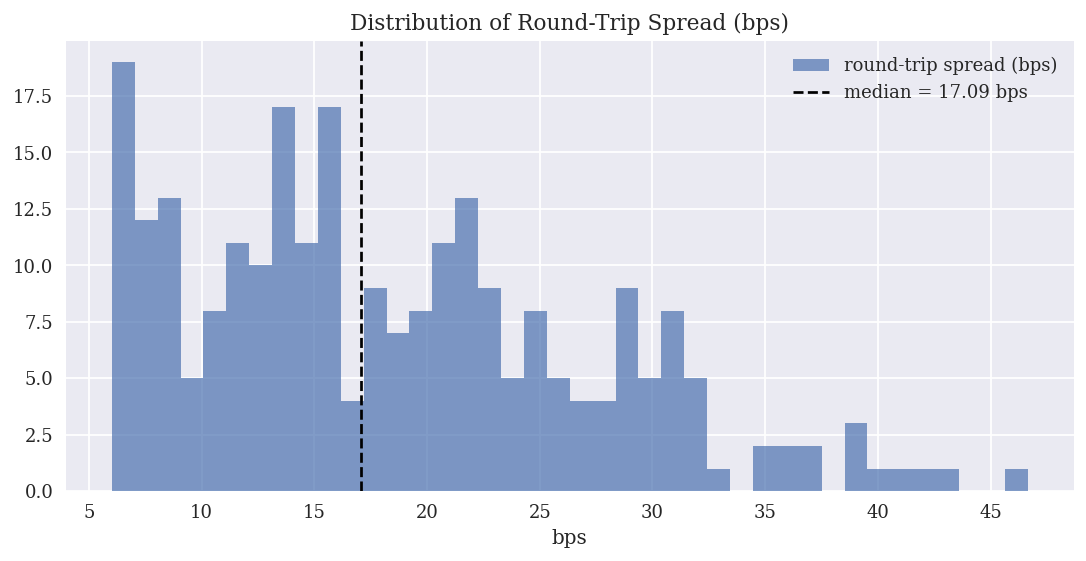

In [6]:
# effective round-trip cost on a notional
NOTIONAL = 1_000_000            # 1M EUR traded
oneway_eur = NOTIONAL * np.median(half)
roundtrip_eur = 2 * oneway_eur
print(f'Notional traded          : {NOTIONAL:,.0f} EUR')
print(f'Median one-way cost      : {oneway_eur:,.2f} EUR')
print(f'Median round-trip cost   : {roundtrip_eur:,.2f} EUR')
print(f'Round-trip as bps        : {2 * np.median(half_bp):.2f} bps')

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.hist(2 * fx['half_bp'], bins=40, alpha=0.7, label='round-trip spread (bps)')
ax.axvline(2 * np.median(half_bp), color='k', ls='--', lw=1.5,
            label=f'median = {2*np.median(half_bp):.2f} bps')
ax.legend()
ax.set(title='Distribution of Round-Trip Spread (bps)', xlabel='bps')
plt.show()

## Step 3 &mdash; Market Depth and Slippage

The spread tells you the cost of a **small** trade. For a **large** trade you walk through the order book and consume depth at progressively worse prices &mdash; this is **slippage / market impact**. We model a simple limit-order book: discrete **levels** away from the best bid, each holding a limited quantity, with less depth further from the mid.

The **average execution price** for a market-buy order of size $Q$ is the quantity-weighted average of the price levels it consumes. The **impact** is the difference between that average and the pre-trade mid rate.

In [7]:
# --- model a one-sided ask-side order book ---
levels = 8
step = 1.0            # bps between levels
base_depth = 250_000  # EUR available at best level

price_off_bp = step * np.arange(1, levels + 1)          # 1..8 bps
price_off = price_off_bp / 10000
depth = base_depth / (1 + np.arange(levels))            # decreasing depth

def avg_exec(Q, mid_now, off, dep, verbose=False):
    '''Quantity-weighted average ask price when buying size Q.'''
    pxs = mid_now * (1 + off)
    cum = np.cumsum(dep)
    fill = np.minimum(dep, np.maximum(0, Q - np.concatenate([[0.], cum[:-1]])))
    total = fill.sum()
    avg = np.average(pxs, weights=fill) if total > 0 else np.nan
    if verbose:
        print(f'Q = {Q:>10,.0f}  avg exec = {avg:.5f}  impact = {avg/mid_now - 1:+.4f}')
    return avg

mid_now = fx['S'].iloc[-1]
print('Order book (ask side):', [(f'{o*10000:.0f} bps', f'{d:,.0f} EUR') for o, d in zip(price_off, depth)])

for Q in [100_000, 500_000, 1_000_000, 2_000_000]:
    avg_exec(Q, mid_now, price_off, depth, verbose=True)

Order book (ask side): [('1 bps', '250,000 EUR'), ('2 bps', '125,000 EUR'), ('3 bps', '83,333 EUR'), ('4 bps', '62,500 EUR'), ('5 bps', '50,000 EUR'), ('6 bps', '41,667 EUR'), ('7 bps', '35,714 EUR'), ('8 bps', '31,250 EUR')]
Q =    100,000  avg exec = 1.15176  impact = +0.0001
Q =    500,000  avg exec = 1.15185  impact = +0.0002
Q =  1,000,000  avg exec = 1.15198  impact = +0.0003
Q =  2,000,000  avg exec = 1.15198  impact = +0.0003


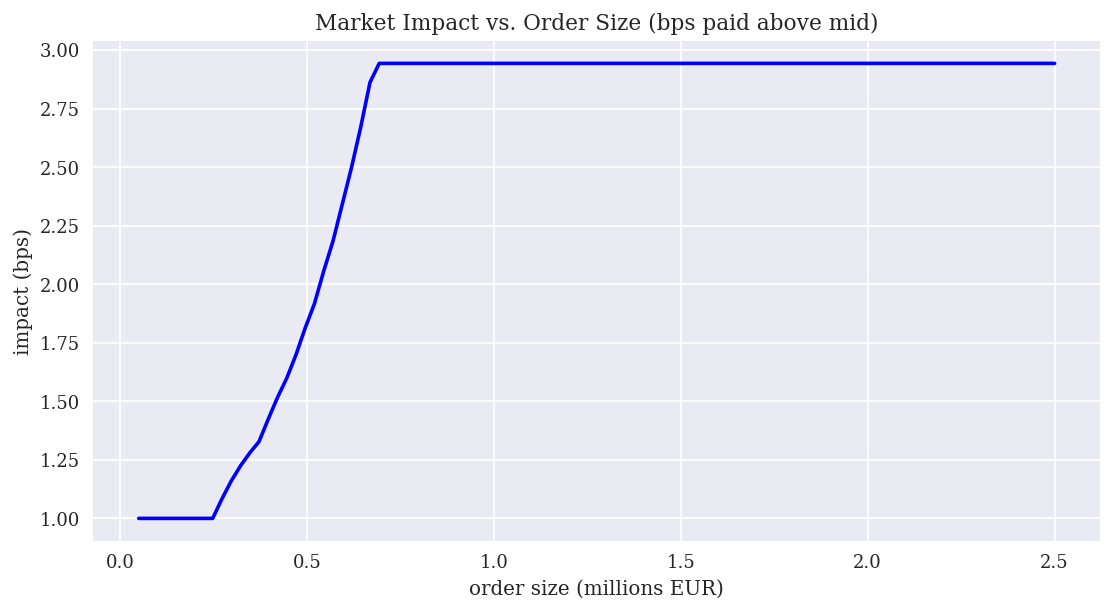

In [8]:
# impact as a function of order size
Qs = np.linspace(50_000, 2_500_000, 100)
impacts = []
for Q in Qs:
    a = avg_exec(Q, mid_now, price_off, depth)
    impacts.append(a / mid_now - 1)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(Qs / 1e6, np.array(impacts) * 10000, lw=2, color='b')
ax.set(title='Market Impact vs. Order Size (bps paid above mid)',
       xlabel='order size (millions EUR)', ylabel='impact (bps)')
ax.grid(True)
plt.show()

## Step 4 &mdash; The Amihud Illiquidity Measure

A compact, data-driven proxy for illiquidity combines **return magnitude** with **volume**: an illiquid asset moves a lot in price with little trading volume. The **Amihud illiquidity ratio** is the average absolute return per unit of **(dollar) volume**:

$$\text{ILLIQ}_t = \frac{1}{N}\;\sum_{t} \frac{|r_t|}{V_t}$$

($V_t$ = traded volume in the base currency). A high value means large price moves per unit of trading, i.e. low liquidity. We synthesize daily volume that is **negatively correlated** with spread (thin volume when spreads are wide) to make the two measures consistent.

Corr(spread, 1/volume)  = +0.601
Mean absolute ret        = 0.00344
Mean volume (EUR)        = 1,026,235,127
Amihud illiquidity       = 0.008


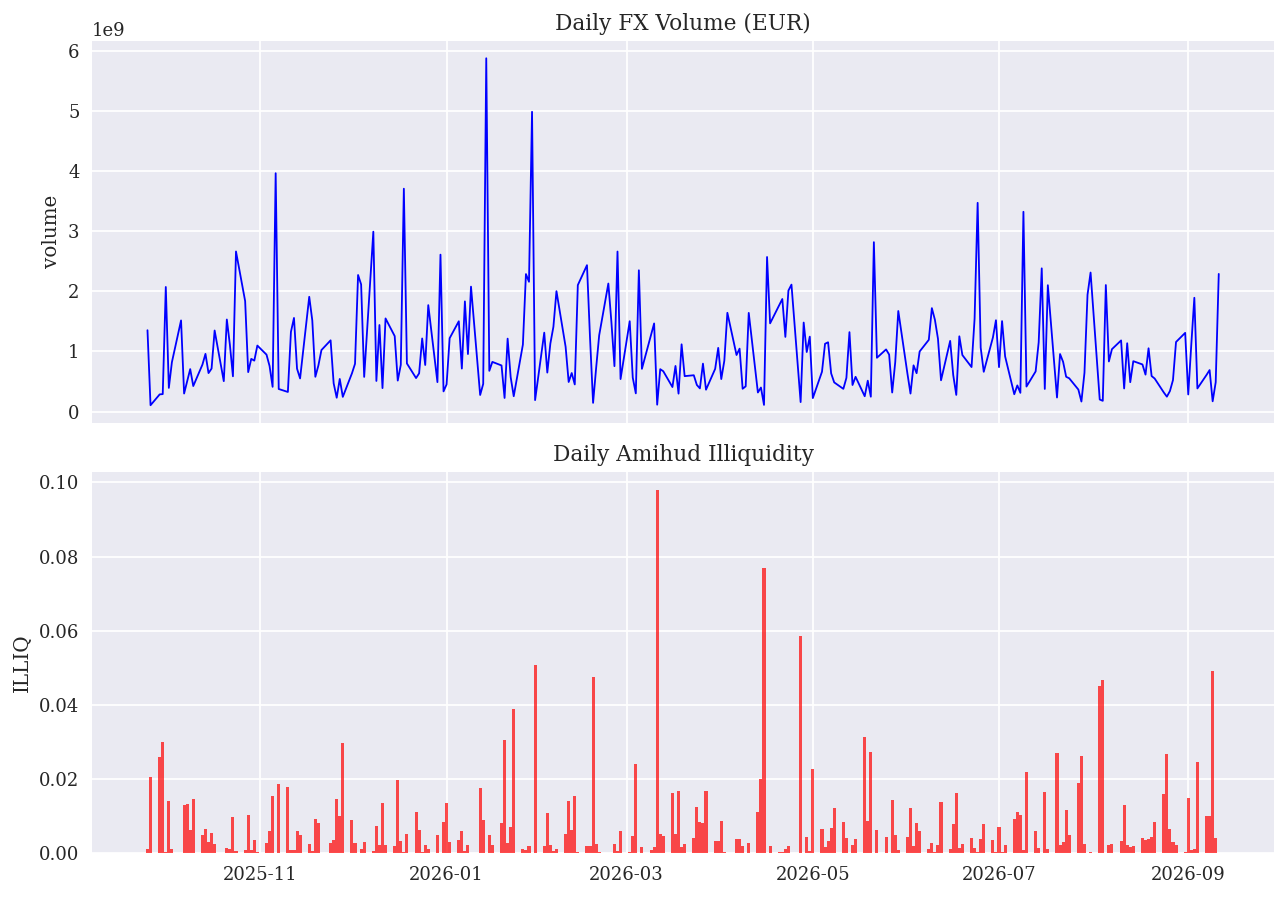

In [9]:
# synthetic dollar volume: log-normal, negatively related to spread width
spread_norm = (fx['half_bp'] - fx['half_bp'].mean()) / fx['half_bp'].std()
log_vol = 20.5 - 0.5 * spread_norm + 0.6 * rng.standard_normal(len(fx))
volume = np.exp(log_vol)          # daily traded volume (EUR)

# ILLIQ per (million EUR traded), scaled for readability
amihud = (np.abs(fx['r'].values) / (volume / 1e6)) * 1e3
amihud_ratio = np.mean(amihud)

print(f'Corr(spread, 1/volume)  = {np.corrcoef(fx["half_bp"], 1/volume)[0,1]:+.3f}')
print(f'Mean absolute ret        = {np.mean(np.abs(fx["r"])):.5f}')
print(f'Mean volume (EUR)        = {np.mean(volume):,.0f}')
print(f'Amihud illiquidity       = {amihud_ratio:.3f}')

fx['volume'] = volume
fx['amihud_daily'] = (np.abs(fx['r'].values) / (volume / 1e6)) * 1e3

fig, ax = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
ax[0].plot(fx['volume'], lw=1.0, color='b')
ax[0].set(title='Daily FX Volume (EUR)', ylabel='volume')
ax[1].bar(fx.index, fx['amihud_daily'], width=1.0, color='r', alpha=0.7)
ax[1].set(title='Daily Amihud Illiquidity', ylabel='ILLIQ')
plt.tight_layout()
plt.show()

## Step 5 &mdash; Liquidity-Adjusted VaR (LVaR)

Standard **Value at Risk** only captures **market risk**: the distribution of the mid rate. It ignores the fact that liquidating a position costs money. **Liquidity-adjusted VaR (LVaR)** adds a **liquidity premium** for the cost of unwinding the position:

$$\text{LVaR}_{\alpha} = \text{VaR}_{\alpha}(P) + k \cdot P \cdot \text{impact}(P)$$

where $P$ is the position, $\text{VaR}_{\alpha}(P)$ is the market-risk loss at level $\alpha$, and $k\cdot P\cdot\text{impact}(P)$ is the cost (and related convexity) of liquidating $P$. For a position traded *up to* liquidity limits, LVaR exceeds VaR by roughly the **half-spread** plus a fraction of the **impact cost** of the liquidation size.

In [10]:
from scipy.stats import norm

alpha = 0.99
z = norm.ppf(alpha)
POSITION = 5_000_000          # EUR position to value

# --- market risk VaR (daily, parametric on mid returns) ---
vol_d = fx['r'].std()
mu_d = fx['r'].mean()
var_market = POSITION * (mu_d - z * vol_d)   # positive = expected loss in tail

# --- liquidity add-on: half-spread + impact cost of unwinding ---
half_now = np.median(fx['half_bp']) / 10000
impact_now = avg_exec(POSITION, fx['S'].iloc[-1], price_off, depth) / fx['S'].iloc[-1] - 1
liq_cost = POSITION * (half_now + impact_now)

lvar = abs(var_market) + liq_cost

print(f'Position (EUR)            : {POSITION:,.0f}')
print(f'Market-risk VaR (99%,1d)  : {abs(var_market):,.0f} EUR  ({abs(var_market)/POSITION*100:.2f}%)')
print(f'Liquidity add-on          : {liq_cost:,.0f} EUR  ({liq_cost/POSITION*100:.2f}%)')
print(f'Liquidity-adjusted VaR    : {lvar:,.0f} EUR  ({lvar/POSITION*100:.2f}%)')
print(f'LVaR / VaR ratio          : {lvar/abs(var_market):.2f}x')

Position (EUR)            : 5,000,000
Market-risk VaR (99%,1d)  : 47,790 EUR  (0.96%)
Liquidity add-on          : 5,743 EUR  (0.11%)
Liquidity-adjusted VaR    : 53,533 EUR  (1.07%)
LVaR / VaR ratio          : 1.12x


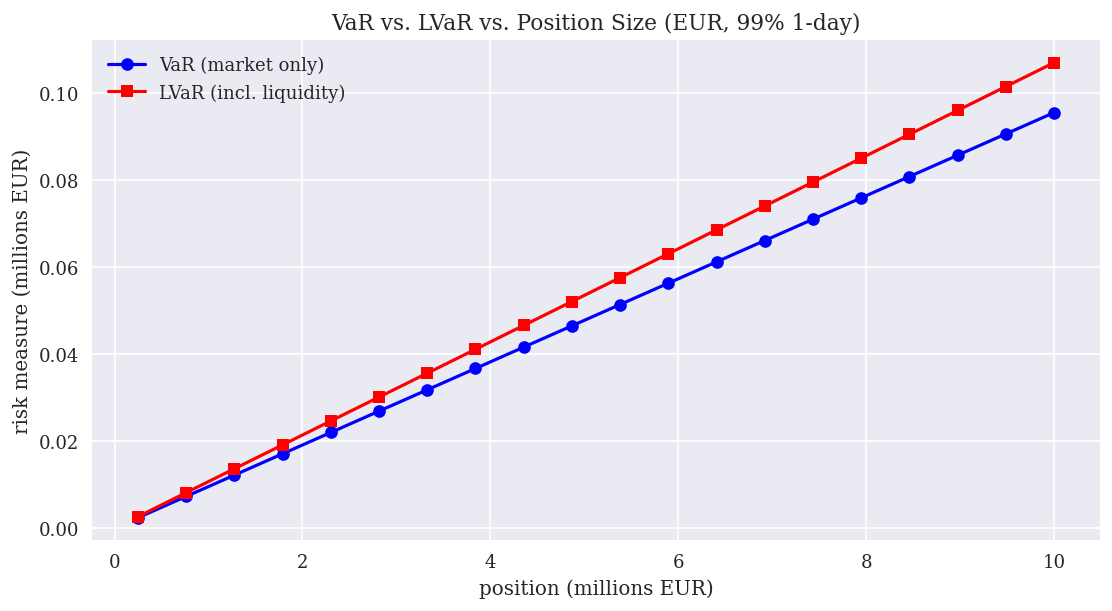

In [11]:
# LVaR sensitivity to position size (bigger -> more impact -> higher add-on)
positions = np.linspace(250_000, 10_000_000, 20)
lvars, var_mkts = [], []
fx_last = fx['S'].iloc[-1]
for P in positions:
    vm = P * (mu_d - z * vol_d)
    imp = avg_exec(P, fx_last, price_off, depth) / fx_last - 1
    lv = abs(vm) + P * (half_now + imp)
    var_mkts.append(abs(vm)); lvars.append(lv)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(positions/1e6, np.array(var_mkts)/1e6, 'o-', label='VaR (market only)', color='b')
ax.plot(positions/1e6, np.array(lvars)/1e6, 's-', label='LVaR (incl. liquidity)', color='r')
ax.set(title='VaR vs. LVaR vs. Position Size (EUR, 99% 1-day)',
       xlabel='position (millions EUR)', ylabel='risk measure (millions EUR)')
ax.legend()
ax.grid(True)
plt.show()

## Step 6 &mdash; Funding Liquidity: Settlement (Herstatt) Risk

Whereas Steps 2&ndash;5 quantified *market* liquidity, **funding liquidity** is about having the **right currency in the right amount at the right time**. For an FX provider, the classic risk is **settlement (Herstatt) risk**: you pay out one leg of a transaction but the counterpart does not deliver the other leg &mdash; you are out the full notional for the period.

We model a simplified **payment/settlement ledger**: a series of outgoing payment obligations denominated in USD, an incoming flow of EUR, and the requirement to hold a **pre-funded USD balance** to cover outflows. When the pre-funded balance is insufficient for an outgoing leg, a **funding gap** occurs that must be financed (e.g. via a credit line or an emergency FX conversion).

Days with funding gap : 105 of 252
Min pre-funded balance: -1,925,421 EUR
Max drawdown from 0   : 1,925,421 EUR
P(funding gap)        : 0.42


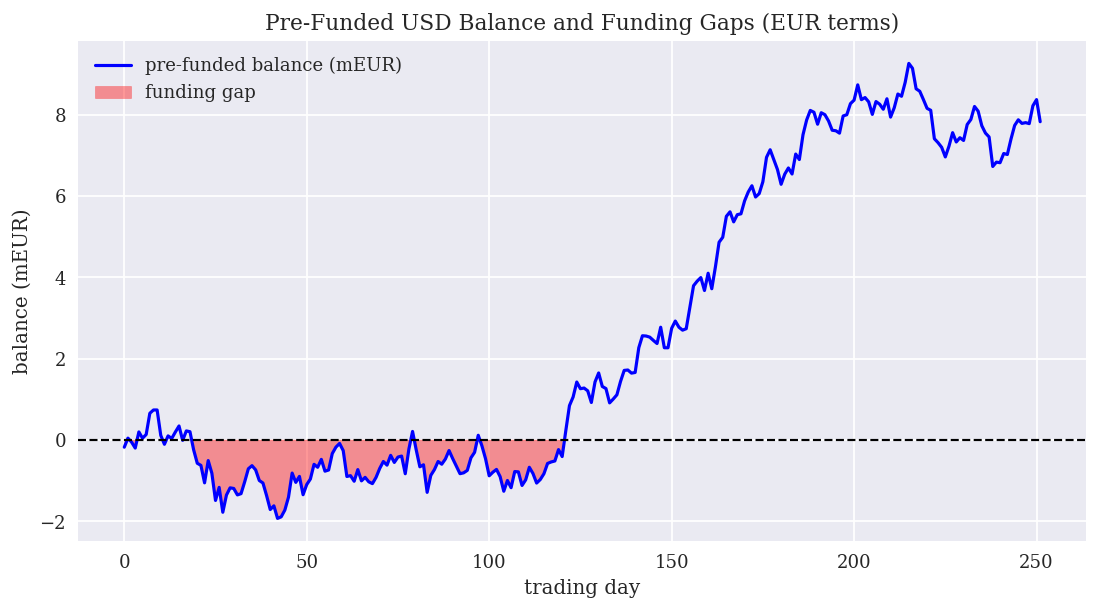

In [12]:
np.random.seed(1000)
N = 252    # trading days

# daily EUR inflows (revenue) and an FX-rate-dependent net daily surplus
inflow_eur = 1_200_000 + 150_000 * np.random.randn(N)
# net EUR surplus after collecting incoming and paying outgoing flows
net = 20_000 + 300_000 * np.random.randn(N)

# pre-funded USD balance (in EUR terms), initial + net daily change
init_balance = 200_000
balance = init_balance + np.cumsum(net)

# funding gap: when balance is negative we must borrow/convert at a penalty
gap = balance < 0

print(f'Days with funding gap : {gap.sum()} of {N}')
print(f'Min pre-funded balance: {balance.min():,.0f} EUR')
print(f'Max drawdown from 0   : {max(0, -balance.min()):,.0f} EUR')
print(f'P(funding gap)        : {gap.mean():.2f}')

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(balance / 1e6, label='pre-funded balance (mEUR)', color='b')
ax.axhline(0, color='k', ls='--', lw=1.2)
ax.fill_between(np.arange(N), balance/1e6, 0, where=gap,
                color='r', alpha=0.4, label='funding gap')
ax.set(title='Pre-Funded USD Balance and Funding Gaps (EUR terms)',
       ylabel='balance (mEUR)', xlabel='trading day')
ax.legend()
plt.show()

In [13]:
# cost of funding gaps at a penalty rate on the shortfall
penalty_annual = 0.04          # 4% annual borrowing cost
penalty_daily = penalty_annual / 252
shortfall = np.maximum(0, -balance)
cost = shortfall * penalty_daily
print(f'Total 1-day funding cost : {cost.sum():,.0f} EUR')
print(f'Total shortfall (EUR)     : {shortfall.sum():,.0f} EUR')

# expected shortfall measure on the balance (loss beyond zero)
es = balance[gap].mean() if gap.any() else 0.0
print(f'Expected shortfall (neg)  : {es:,.0f} EUR')

Total 1-day funding cost : 13,210 EUR
Total shortfall (EUR)     : 83,222,598 EUR
Expected shortfall (neg)  : -792,596 EUR


## Step 7 &mdash; Mitigating FX Liquidity Risk

Best-practice levers for an FX provider to manage liquidity risk:

1. **Pre-funding buffers** &mdash; hold a cushion of pre-funded foreign-currency balances to absorb funding gaps without forced, expensive conversions.
2. **Credit lines / liquidity facilities** &mdash; prearranged borrowing capacity to bridge shortfalls.
3. **Internal netting & recycling** &mdash; offset opposing flows across currencies/timings to shrink gross settlement exposures.
4. **Settlement risk reduction** &mdash; use payment-versus-payment (PVP) and CLS to eliminate Herstatt risk.
5. **Execution discipline** &mdash; split large orders, use smart order routing, and cap position **relative to market depth** to keep impact bounded.

Below we show the effect of **raising the pre-funding buffer** on the probability of a funding gap.

              P(gap)  total shortfall
buffer (EUR)                         
0              0.452     1.050211e+08
100000         0.429     9.389106e+07
250000         0.413     7.801583e+07
500000         0.361     5.354546e+07
1000000        0.198     1.681673e+07


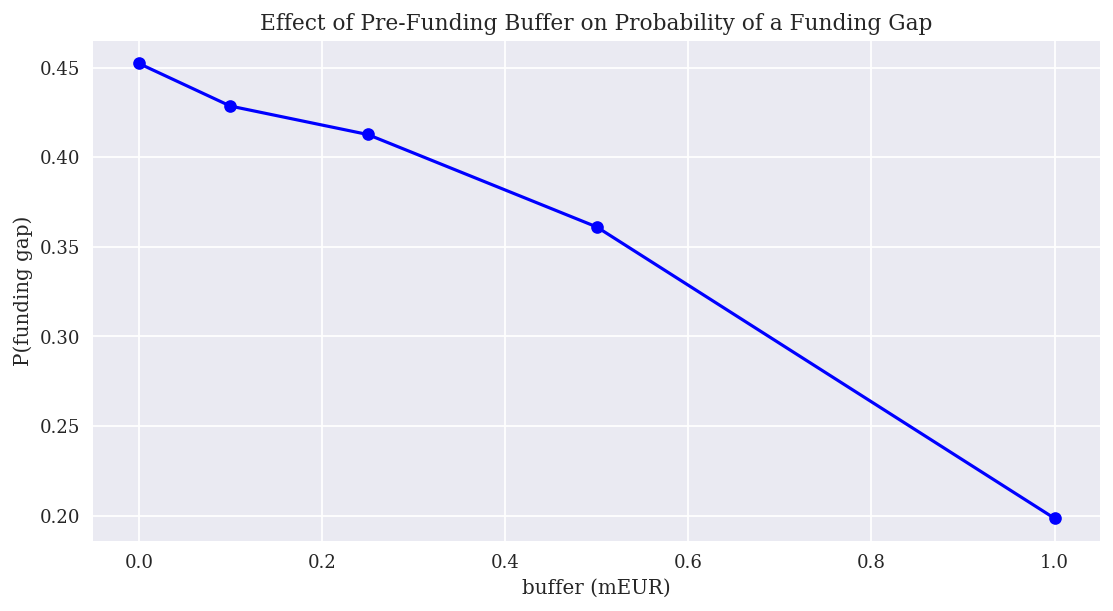

In [14]:
buffers = np.array([0, 100_000, 250_000, 500_000, 1_000_000])
gap_probs, gap_shortfail = [], []
for b in buffers:
    bal = b + np.cumsum(net)
    g = bal < 0
    gap_probs.append(g.mean())
    gap_shortfail.append(np.maximum(0, -bal).sum())

res = pd.DataFrame({'buffer (EUR)': buffers,
                    'P(gap)': gap_probs,
                    'total shortfall': gap_shortfail}).set_index('buffer (EUR)')
print(res.round(3))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(buffers/1e6, gap_probs, 'o-', color='b')
ax.set(title='Effect of Pre-Funding Buffer on Probability of a Funding Gap',
       xlabel='buffer (mEUR)', ylabel='P(funding gap)')
ax.grid(True)
plt.show()

## Summary

- **Liquidity risk** has two faces: **market** liquidity (ability to transact at fair prices) and **funding** liquidity (ability to meet payment/settlement obligations). An FX / money-transfer provider is exposed to both.
- **Market liquidity** is measured by the **bid-ask spread**, **order-book depth**, **slippage / market impact**, and the **Amihud illiquidity ratio**. Spreads and impact *widen* exactly when volatility rises &mdash; liquidity is a *conditional*, stress-dependent feature.
- **LVaR** extends ordinary VaR with a **liquidity premium** for the cost (and impact) of liquidating a position; the add-on grows with position size relative to market depth.
- **Funding liquidity risk** (incl. **Herstatt / settlement** risk) is managed by **pre-funding** buffers, **credit lines**, **netting & recycling**, and **PVP / CLS-style settlement**, plus **execution discipline** that keeps positions proportional to available depth.

## Further Reading

- Y. Hilpisch, *Reinforcement Learning for Finance* (O'Reilly, 2024)
- Y. Hilpisch, *Python for Finance* (O'Reilly, 2nd ed., 2018)
- J. Hull, *Options, Futures, and Other Derivatives* (Pearson, 11th ed.)

---
&copy; Dr. Yves J. Hilpisch | The Python Quants GmbH | This notebook is for educational purposes and does **not** constitute investment advice.